# Random Forest Classification: 3s / 25 Segments

This notebook trains and evaluates a Random Forest classifier using MFCC mean and standard deviation features extracted from 25 random 3-second segments per track.

A validation-based hyperparameter search is used to select suitable Random Forest parameters before final test evaluation.

In [ ]:
import sys
from pathlib import Path

current_path = Path.cwd()

for parent in [current_path] + list(current_path.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        break
else:
    raise FileNotFoundError("Could not find project root containing 'src' folder.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)
from sklearn.model_selection import ParameterGrid

from src.config import (
    MFCC_MEAN_TRAIN_PKL,
    MFCC_MEAN_VAL_PKL,
    MFCC_MEAN_TEST_PKL,
    MODEL_RESULTS_DIR,
    RANDOM_STATE
)

from src.model_functions import prepare_features_labels

In [12]:
# ============================================================
# CONFIGURATION
# Central place to control all experiment parameters
# ============================================================

MODEL_NAME = "RandomForest_3s_25"

TARGET_COL = "genre"

NORMALIZE_FEATURES = True
REDUCTION_FACTOR = 1.0

In [ ]:
# Read in pkl-Files which contain means of mfccs
df_features_tracks_train = pd.read_pickle(MFCC_MEAN_TRAIN_PKL)
df_features_tracks_val = pd.read_pickle(MFCC_MEAN_VAL_PKL)
df_features_tracks_test = pd.read_pickle(MFCC_MEAN_TEST_PKL)


In [ ]:
X_train, y_train, X_val, y_val, X_test, y_test = prepare_features_labels(
    df_features_tracks_train,
    df_features_tracks_val,
    df_features_tracks_test,
    target_col=TARGET_COL,
    normalize_features=NORMALIZE_FEATURES,
    reduction_factor=REDUCTION_FACTOR,
    random_state=RANDOM_STATE
)

## Hyperparameter Search

A small validation-based hyperparameter search is used to compare selected Random Forest configurations. The model is trained on the training set and evaluated on the validation set. Macro-F1 is used as the selection criterion.

In [ ]:
# Define the hyperparameter grid for the Random Forest model.
# Each combination of these values will be tested on the validation set.
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500, 600],      # Number of trees in the forest
    "max_depth": [None, 10, 15, 20, 25, 30],         # Maximum depth of each tree; None means unlimited depth
    "min_samples_split": [2, 5, 7, 10],     # Minimum number of samples required to split an internal node
    "max_features": ["sqrt", "log2"]        # Number of features considered at each split
}

# Store the validation results for all tested parameter combinations.
search_results = []

# Variables for tracking the best model configuration.
best_model = None
best_params = None
best_macro_f1 = -1

# Iterate over all possible hyperparameter combinations.
for params in ParameterGrid(param_grid):
    print(f"Training with parameters: {params}")

    # Initialize a Random Forest model with the current parameter combination.
    rf = RandomForestClassifier(
        **params,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Train the model on the training data.
    rf.fit(X_train, y_train)

    # Predict the validation labels.
    y_val_pred_search = rf.predict(X_val)

    # Calculate validation metrics for the current parameter combination.
    val_accuracy = accuracy_score(y_val, y_val_pred_search)
    val_macro_f1 = f1_score(y_val, y_val_pred_search, average="macro")

    # Store the parameter combination and its validation results.
    search_results.append({
        **params,
        "val_accuracy": val_accuracy,
        "val_macro_f1": val_macro_f1
    })

    # Print the validation performance for monitoring.
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Macro-F1: {val_macro_f1:.4f}")
    print("-" * 60)

    # Update the best model if the current configuration achieves a higher Macro-F1 score.
    if val_macro_f1 > best_macro_f1:
        best_macro_f1 = val_macro_f1
        best_params = params
        best_model = rf

# Convert all search results into a DataFrame for comparison.
search_results_df = pd.DataFrame(search_results)

# Sort the results by validation Macro-F1 in descending order.
search_results_df.sort_values("val_macro_f1", ascending=False)

Training with parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Validation Accuracy: 0.6312
Validation Macro-F1: 0.6175
------------------------------------------------------------
Training with parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Validation Accuracy: 0.6313
Validation Macro-F1: 0.6171
------------------------------------------------------------
Training with parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Validation Accuracy: 0.6351
Validation Macro-F1: 0.6207
------------------------------------------------------------
Training with parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 400}
Validation Accuracy: 0.6355
Validation Macro-F1: 0.6211
------------------------------------------------------------
Training with parameters: {'max_depth': None, 'max_features': 'sqrt', 'm

,max_depth,max_features,min_samples_split,n_estimators,val_accuracy,val_macro_f1
250,30.0,sqrt,5,500,0.638962,0.626148
269,30.0,log2,2,600,0.639340,0.625454
251,30.0,sqrt,5,600,0.637830,0.624947
211,25.0,sqrt,10,200,0.638019,0.624822
47,NaN,log2,10,600,0.638019,0.624600
...,...,...,...,...,...,...
57,10.0,sqrt,5,400,0.601887,0.572170
56,10.0,sqrt,5,300,0.601981,0.571790
84,10.0,log2,7,100,0.600566,0.571388
54,10.0,sqrt,5,100,0.600566,0.571322


In [19]:
print("Best parameters:")
print(best_params)

print(f"Best validation Macro-F1: {best_macro_f1:.4f}")

Best parameters:
{'max_depth': 30, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 500}
Best validation Macro-F1: 0.6261


In [20]:
clf = best_model

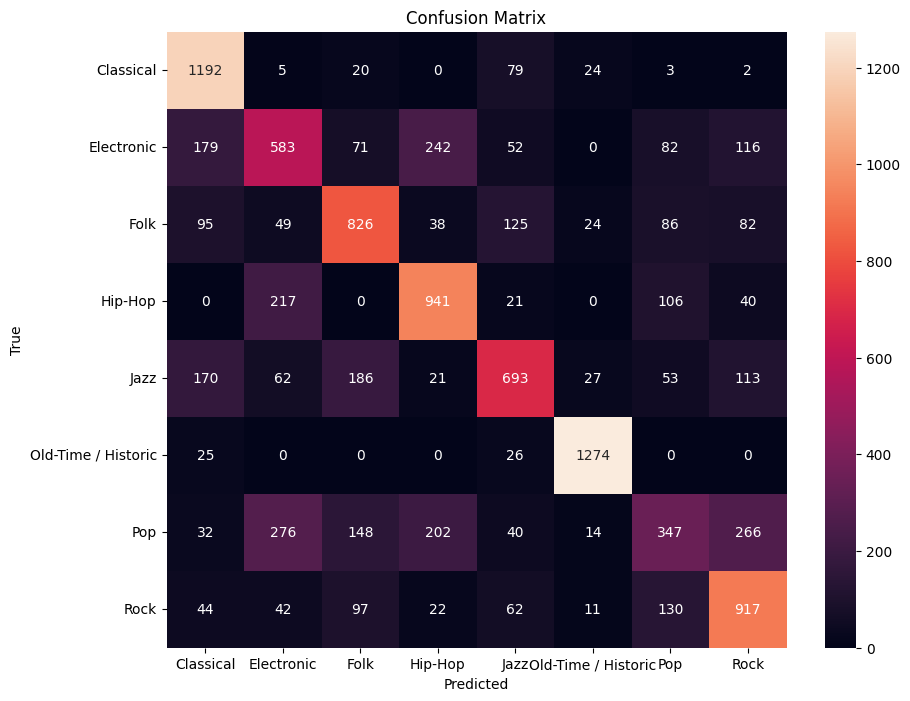

Classification Report Validation Set:
                      precision    recall  f1-score   support

          Classical       0.69      0.90      0.78      1325
         Electronic       0.47      0.44      0.46      1325
               Folk       0.61      0.62      0.62      1325
            Hip-Hop       0.64      0.71      0.67      1325
               Jazz       0.63      0.52      0.57      1325
Old-Time / Historic       0.93      0.96      0.94      1325
                Pop       0.43      0.26      0.33      1325
               Rock       0.60      0.69      0.64      1325

           accuracy                           0.64     10600
          macro avg       0.62      0.64      0.63     10600
       weighted avg       0.62      0.64      0.63     10600

Balanced Accuracy: 0.6389622641509434
F1-Macro: 0.6261484188570411


In [21]:
# ---------------------------------------------------
# CONFUSION MATRIX VALIDATION SET
# ---------------------------------------------------
y_pred_val = clf.predict(X_val)

cm = confusion_matrix(y_val, y_pred_val,labels=clf.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report Validation Set:\n", classification_report(y_val, y_pred_val, target_names=clf.classes_))

# Balanced Accuracy
print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_pred_val))

# F1-Macro
print("F1-Macro:", f1_score(y_val, y_pred_val, average='macro'))


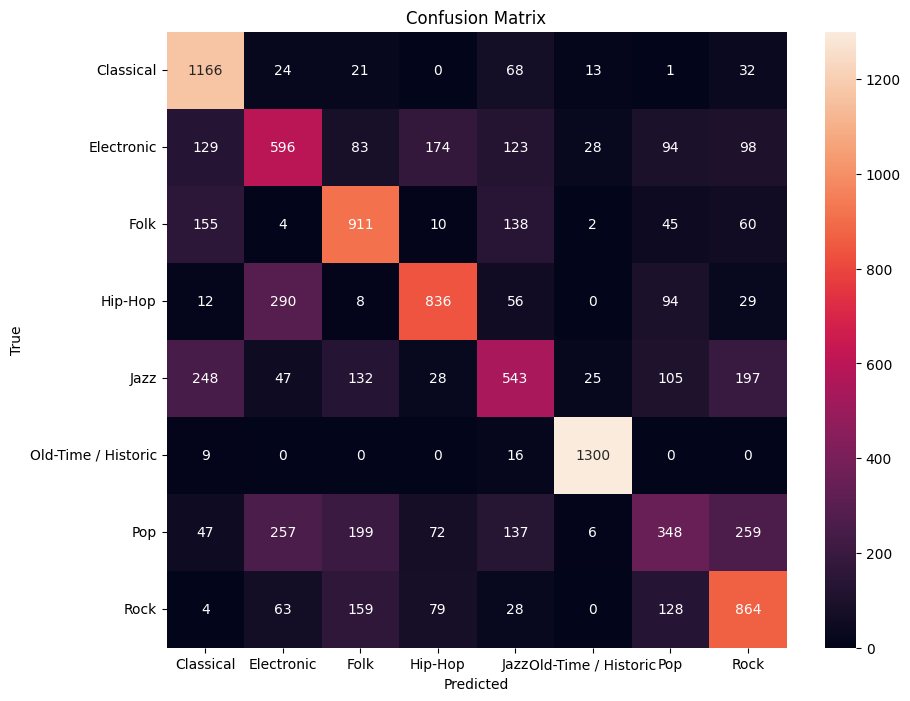

Classification Report Test Set:
                      precision    recall  f1-score   support

          Classical       0.66      0.88      0.75      1325
         Electronic       0.47      0.45      0.46      1325
               Folk       0.60      0.69      0.64      1325
            Hip-Hop       0.70      0.63      0.66      1325
               Jazz       0.49      0.41      0.45      1325
Old-Time / Historic       0.95      0.98      0.96      1325
                Pop       0.43      0.26      0.33      1325
               Rock       0.56      0.65      0.60      1325

           accuracy                           0.62     10600
          macro avg       0.61      0.62      0.61     10600
       weighted avg       0.61      0.62      0.61     10600

Accuracy: 0.6192452830188679
Balanced Accuracy: 0.6192452830188679
F1-Macro: 0.6066757234353788


In [22]:
# ---------------------------------------------------
# CONFUSION MATRIX TEST SET
# ---------------------------------------------------

y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred,labels=clf.classes_)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("Classification Report Test Set:\n", classification_report(y_test, y_pred, target_names=clf.classes_))

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Balanced Accuracy
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

# F1-Macro
print("F1-Macro:", f1_score(y_test, y_pred, average='macro'))


In [23]:
# ---------------------------------------------------------
# IDENTIFY MISCLASSIFIED TEST SAMPLES
# ---------------------------------------------------------

# Create analysis DataFrame
# Create a copy of the original test DataFrame
# This ensures the original data remains unchanged
analysis_df = df_features_tracks_test.copy()
analysis_df['true_genre'] = y_test.astype(str)
analysis_df['predicted_genre'] = y_pred.astype(str)

# Identify misclassified samples
# Filter rows where prediction does not match the true label
misclassified = analysis_df[analysis_df['true_genre'] != analysis_df['predicted_genre']]

# Print misclassification DataFrame
print(misclassified[['track_id', 'true_genre', 'predicted_genre']])

      track_id true_genre      predicted_genre
118     032044  Classical  Old-Time / Historic
200     037979  Classical                 Jazz
201     037979  Classical                 Rock
202     037979  Classical                 Jazz
203     037979  Classical                 Jazz
...        ...        ...                  ...
10595   001287       Rock              Hip-Hop
10596   001287       Rock              Hip-Hop
10597   001287       Rock              Hip-Hop
10598   001287       Rock                  Pop
10599   001287       Rock                  Pop

[4036 rows x 3 columns]


In [ ]:
# ---------------------------------------------------------
# AGGREGATE MISCLASSIFICATIONS AT TRACK LEVEL
# ---------------------------------------------------------

# Group misclassified segments by track_id and true_genre
# For each track, determine the most frequently predicted (wrong) genre
# This is useful if multiple segments belong to the same track
track_level_preds = (
    misclassified
    .groupby(['track_id', 'true_genre'])['predicted_genre']
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
)

# Print aggregated track-level misclassifications
print(track_level_preds)

# Save results to CSV
track_level_preds[['track_id', 'true_genre', 'predicted_genre']].to_csv(MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority_voting.csv", index=False)

    track_id  true_genre predicted_genre
0     000145        Jazz            Rock
1     000336        Rock      Electronic
2     000406  Electronic            Rock
3     000575        Rock         Hip-Hop
4     000663  Electronic            Jazz
..       ...         ...             ...
274   154406         Pop         Hip-Hop
275   154407         Pop            Folk
276   154430        Jazz       Classical
277   154433        Jazz      Electronic
278   155306        Folk       Classical

[279 rows x 3 columns]



=== SEGMENT-LEVEL TEST EVALUATION ===
Accuracy: 0.6192452830188679
Macro-F1: 0.6066757234353788

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.66      0.88      0.75      1325
         Electronic       0.47      0.45      0.46      1325
               Folk       0.60      0.69      0.64      1325
            Hip-Hop       0.70      0.63      0.66      1325
               Jazz       0.49      0.41      0.45      1325
Old-Time / Historic       0.95      0.98      0.96      1325
                Pop       0.43      0.26      0.33      1325
               Rock       0.56      0.65      0.60      1325

           accuracy                           0.62     10600
          macro avg       0.61      0.62      0.61     10600
       weighted avg       0.61      0.62      0.61     10600


=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===
Accuracy: 0.6745283018867925
Macro-F1: 0.6630413394640746

Classification Report:
        

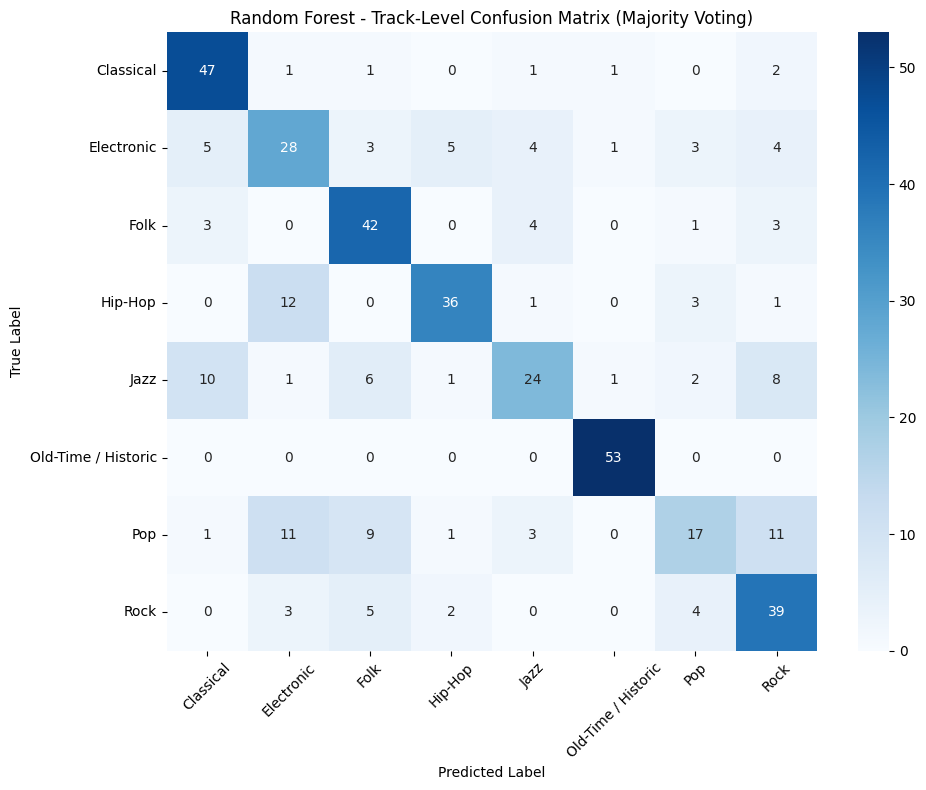


=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===
Accuracy: 0.6556603773584906
Macro-F1: 0.643680545673254

Classification Report:
                     precision    recall  f1-score   support

          Classical       0.65      0.91      0.76        53
         Electronic       0.49      0.51      0.50        53
               Folk       0.59      0.70      0.64        53
            Hip-Hop       0.77      0.68      0.72        53
               Jazz       0.67      0.42      0.51        53
Old-Time / Historic       0.95      0.98      0.96        53
                Pop       0.53      0.32      0.40        53
               Rock       0.60      0.74      0.66        53

           accuracy                           0.66       424
          macro avg       0.65      0.66      0.64       424
       weighted avg       0.65      0.66      0.64       424



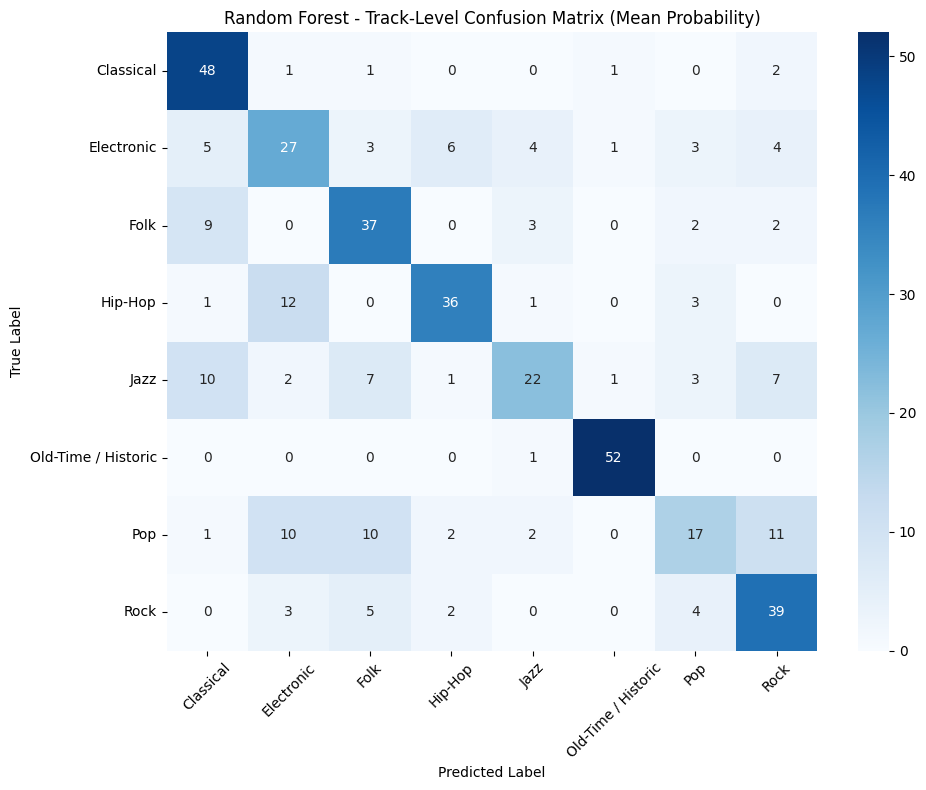


Saved segment- and track-level result CSV files to:
J:/Documents/FH/Git Repo Processing/MA_FMA_Dataprocessing/Models_final/Results


In [ ]:
# ---------------------------------------------------------
# TRACK-LEVEL EVALUATION (TEST SET)
# ---------------------------------------------------------
# The model was trained and evaluated on 3-second segments.
# For a track-level evaluation, all segment predictions belonging to the same
# track_id are aggregated into one final prediction per track.

# Build a metadata DataFrame that has the same row order as X_test / y_test.
# This is required so every segment prediction can be assigned to its original track.
test_meta_df = (
    df_features_tracks_test[df_features_tracks_test["genre"].notna()]
    .reset_index(drop=True)
    .copy()
)

# Safety check: X_test, y_test and metadata must have the same number of rows.
assert len(test_meta_df) == len(y_test) == len(X_test), (
    f"Length mismatch: metadata={len(test_meta_df)}, "
    f"y_test={len(y_test)}, X_test={len(X_test)}"
)

# Segment-level predictions and probabilities.
test_pred_proba = clf.predict_proba(X_test)
segment_pred_labels = clf.predict(X_test)
class_names = list(clf.classes_)

# Store segment-level prediction details in one DataFrame.
segment_analysis_df = test_meta_df[["track_id", "genre"]].copy()
segment_analysis_df["true_genre"] = np.array(y_test).astype(str)
segment_analysis_df["predicted_genre"] = np.array(segment_pred_labels).astype(str)

# Add one probability column per class.
for class_idx, class_name in enumerate(class_names):
    segment_analysis_df[f"prob_{class_name}"] = test_pred_proba[:, class_idx]

# ---------------------------------------------------------
# SEGMENT-LEVEL METRICS
# ---------------------------------------------------------
print("\n=== SEGMENT-LEVEL TEST EVALUATION ===")
print(
    "Accuracy:",
    accuracy_score(
        segment_analysis_df["true_genre"],
        segment_analysis_df["predicted_genre"]
    )
)
print(
    "Macro-F1:",
    f1_score(
        segment_analysis_df["true_genre"],
        segment_analysis_df["predicted_genre"],
        average="macro"
    )
)
print("\nClassification Report:")
print(
    classification_report(
        segment_analysis_df["true_genre"],
        segment_analysis_df["predicted_genre"],
        labels=class_names,
        target_names=class_names
    )
)

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MAJORITY VOTING
# ---------------------------------------------------------
# Majority voting selects the most frequent segment-level class prediction
# as the final prediction for each track.
track_majority_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])["predicted_genre"]
    .agg(lambda x: x.value_counts().idxmax())
    .reset_index()
    .rename(columns={"predicted_genre": "predicted_genre_majority"})
)

print("\n=== TRACK-LEVEL TEST EVALUATION: MAJORITY VOTING ===")
print(
    "Accuracy:",
    accuracy_score(
        track_majority_df["true_genre"],
        track_majority_df["predicted_genre_majority"]
    )
)
print(
    "Macro-F1:",
    f1_score(
        track_majority_df["true_genre"],
        track_majority_df["predicted_genre_majority"],
        average="macro"
    )
)
print("\nClassification Report:")
print(
    classification_report(
        track_majority_df["true_genre"],
        track_majority_df["predicted_genre_majority"],
        labels=class_names,
        target_names=class_names
    )
)

cm_majority = confusion_matrix(
    track_majority_df["true_genre"],
    track_majority_df["predicted_genre_majority"],
    labels=class_names
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_majority,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Track-Level Confusion Matrix (Majority Voting)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# TRACK-LEVEL AGGREGATION: MEAN PROBABILITY
# ---------------------------------------------------------
# Mean probability aggregation averages the predicted class probabilities
# across all segments of the same track and selects the class with the
# highest average probability.
prob_cols = [f"prob_{class_name}" for class_name in class_names]

track_probability_df = (
    segment_analysis_df
    .groupby(["track_id", "true_genre"])[prob_cols]
    .mean()
    .reset_index()
)

# Select the class with the highest mean probability as final track prediction.
mean_prob_values = track_probability_df[prob_cols].to_numpy()
track_probability_df["predicted_genre_mean_probability"] = [
    class_names[idx] for idx in np.argmax(mean_prob_values, axis=1)
]

print("\n=== TRACK-LEVEL TEST EVALUATION: MEAN PROBABILITY ===")
print(
    "Accuracy:",
    accuracy_score(
        track_probability_df["true_genre"],
        track_probability_df["predicted_genre_mean_probability"]
    )
)
print(
    "Macro-F1:",
    f1_score(
        track_probability_df["true_genre"],
        track_probability_df["predicted_genre_mean_probability"],
        average="macro"
    )
)
print("\nClassification Report:")
print(
    classification_report(
        track_probability_df["true_genre"],
        track_probability_df["predicted_genre_mean_probability"],
        labels=class_names,
        target_names=class_names
    )
)

cm_mean_probability = confusion_matrix(
    track_probability_df["true_genre"],
    track_probability_df["predicted_genre_mean_probability"],
    labels=class_names
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_mean_probability,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest - Track-Level Confusion Matrix (Mean Probability)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# SAVE TRACK-LEVEL RESULTS
# ---------------------------------------------------------
# Store segment-level and track-level results for later error analysis.
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Segment-level misclassifications.
segment_misclassified = segment_analysis_df[
    segment_analysis_df["true_genre"] != segment_analysis_df["predicted_genre"]
]

segment_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_segments.csv",
    index=False
)

# Track-level predictions: Majority Voting.
track_majority_export = track_majority_df.rename(
    columns={"predicted_genre_majority": "predicted_genre"}
)

track_majority_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_majority.csv",
    index=False
)

# Track-level predictions: Mean Probability.
track_probability_export = track_probability_df.rename(
    columns={"predicted_genre_mean_probability": "predicted_genre"}
)

track_probability_export[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_track_level_predictions_mean_probability.csv",
    index=False
)

# Track-level misclassifications: Majority Voting.
track_majority_misclassified = track_majority_export[
    track_majority_export["true_genre"] != track_majority_export["predicted_genre"]
]

track_majority_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_majority.csv",
    index=False
)

# Track-level misclassifications: Mean Probability.
track_probability_misclassified = track_probability_export[
    track_probability_export["true_genre"] != track_probability_export["predicted_genre"]
]

track_probability_misclassified[
    ["track_id", "true_genre", "predicted_genre"]
].to_csv(
    MODEL_RESULTS_DIR / f"{MODEL_NAME}_misclassified_tracks_mean_probability.csv",
    index=False
)

print("\nSaved segment- and track-level result CSV files to:")
print(MODEL_RESULTS_DIR)

In [ ]:
# Number of repetitions
N_RUNS = 10

results = []

for seed in range(N_RUNS):
    print(f"Run {seed + 1}/{N_RUNS}")

    # Initialize Random Forest with different random_state
    rf = RandomForestClassifier(
        n_estimators=500,
        max_depth= 30, 
        min_samples_split= 5,
        max_features="sqrt",
        random_state=seed,
        n_jobs=-1
    )

    # Train model
    rf.fit(X_train, y_train)

    # Predict test set
    y_pred = rf.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "run": seed + 1,
        "random_state": seed,
        "accuracy": acc,
        "macro_f1": macro_f1
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Summary statistics
summary = {
    "accuracy_mean": results_df["accuracy"].mean(),
    "accuracy_std": results_df["accuracy"].std(),
    "macro_f1_mean": results_df["macro_f1"].mean(),
    "macro_f1_std": results_df["macro_f1"].std()
}

summary_df = pd.DataFrame([summary])

print("\nIndividual runs:")
print(results_df)

print("\nSummary:")
print(summary_df)

Run 1/10
Run 2/10
Run 3/10
Run 4/10
Run 5/10
Run 6/10
Run 7/10
Run 8/10
Run 9/10
Run 10/10

Individual runs:
   run  random_state  accuracy  macro_f1
0    1             0  0.615943  0.602656
1    2             1  0.616792  0.604417
2    3             2  0.614528  0.601533
3    4             3  0.617453  0.604367
4    5             4  0.617453  0.604416
5    6             5  0.615283  0.601758
6    7             6  0.616981  0.603941
7    8             7  0.617736  0.604716
8    9             8  0.613491  0.599870
9   10             9  0.618019  0.604994

Summary:
   accuracy_mean  accuracy_std  macro_f1_mean  macro_f1_std
0       0.616368       0.00151       0.603267      0.001719
